IMPORTING ALL THE REQUIRED LIBRARIES

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


LOADING ALL THE FILES WHICH ARE REQUIRED


In [8]:
orders=pd.read_csv('/Applications/RetailIQ-Instacart/data/raw/orders.csv')
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [9]:
departments=pd.read_csv('/Applications/RetailIQ-Instacart/data/raw/departments.csv')
aisles=pd.read_csv('/Applications/RetailIQ-Instacart/data/raw/aisles.csv')
orders_products=pd.read_csv('/Applications/RetailIQ-Instacart/data/raw/order_products__prior.csv')
products=pd.read_csv('/Applications/RetailIQ-Instacart/data/raw/products.csv')

Dropping 'eval_set' Column As Its Not Needed

In [10]:
orders=orders.drop(columns=['eval_set'])


DATA QUALITY ASSESSMENT

In [11]:
orders.dtypes
products.dtypes
aisles.dtypes
departments.dtypes
orders_products.dtypes



order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

In [12]:
products.isna().sum()

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

In [13]:
aisles.isna().sum()

aisle_id    0
aisle       0
dtype: int64

In [14]:
departments.isna().sum()

department_id    0
department       0
dtype: int64

In [15]:
orders_products.isna().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [16]:
orders.shape

(3421083, 6)

In [17]:
products.shape


(49688, 4)

In [18]:
aisles.shape

(134, 2)

In [19]:
departments.shape

(21, 2)

In [20]:
orders_products.shape

(32434489, 4)

In [21]:
orders.duplicated().sum()

np.int64(0)

In [22]:
products.duplicated().sum()

np.int64(0)

In [23]:
aisles.duplicated().sum()

np.int64(0)

In [24]:
departments.duplicated().sum()

np.int64(0)

In [25]:
orders_products.duplicated().sum()

np.int64(0)

In [26]:
orders.nunique()

order_id                  3421083
user_id                    206209
order_number                  100
order_dow                       7
order_hour_of_day              24
days_since_prior_order         31
dtype: int64

In [27]:
products.nunique()

product_id       49688
product_name     49688
aisle_id           134
department_id       21
dtype: int64

In [28]:
aisles.nunique()

aisle_id    134
aisle       134
dtype: int64

In [29]:
departments.nunique()

department_id    21
department       21
dtype: int64

In [30]:
orders_products.nunique()

order_id             3214874
product_id             49677
add_to_cart_order        145
reordered                  2
dtype: int64

## PERFORMING EDA


## Business Objective

Analyze customer purchasing behavior, product performance, and shopping patterns to generate actionable business insights that can help improve sales, customer retention, inventory planning, and marketing strategies.

### Customer Behavior

#### 1. Who are the most active customers based on the total number of orders placed ?

In [31]:
# Count total orders placed by each customer

active_customers = (
    orders.groupby("user_id")["order_id"]
          .count()
          .reset_index()
)

# Rename columns

active_customers.columns = ["user_id", "total_orders"]

# Sort in descending order

active_customers = active_customers.sort_values(
    by="total_orders",
    ascending=False
)

# Display Top 10 customers

active_customers.head(10)

,user_id,total_orders
152339,152340,100
185640,185641,100
185523,185524,100
81677,81678,100
70921,70922,100
136869,136870,100
81703,81704,100
119931,119932,100
119834,119835,100
91034,91035,100


So this user_id's are the top 10 users who did the maximum orders .


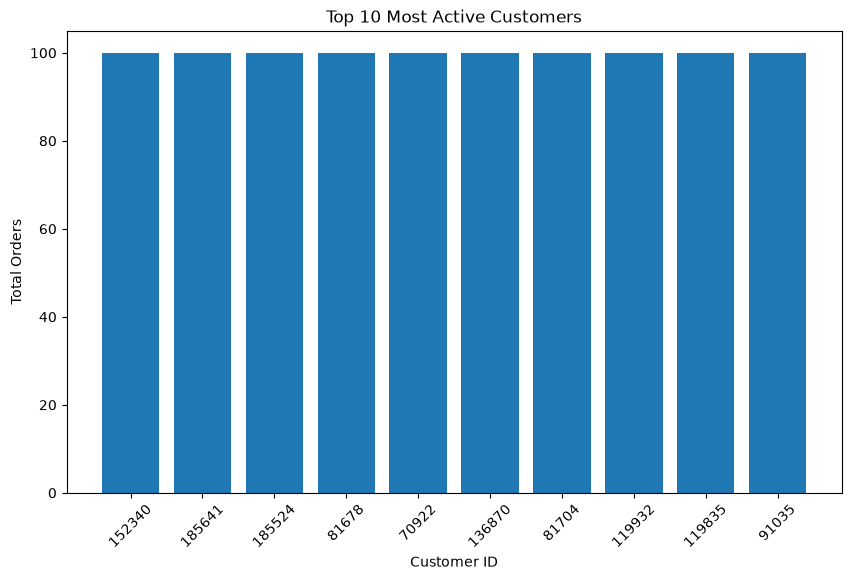

In [32]:
top10 = active_customers.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10["user_id"].astype(str),
    top10["total_orders"]
)

plt.title("Top 10 Most Active Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)

plt.savefig("/Applications/RetailIQ-Instacart/images/top_10_active_customers.png", bbox_inches="tight")
plt.show()

This is the barchart according to the active_customer table for top 10 user_id's.

Objective : Identify customer with the highest purchase frequency to support loyalty and retention stategies


#### 2.⁠ ⁠What is the average number of orders placed per customer?


In [33]:
# Average number of orders placed by per customers
orders_per_customer=(orders.groupby('user_id')['order_id'].count().reset_index(name="total_orders"))
avg_orders_per_customer=orders_per_customer["total_orders"].mean()

print(f"Average orders per customer: {avg_orders_per_customer:.2f}")    

Average orders per customer: 16.59


Hence the average orders per customer is 16.59.

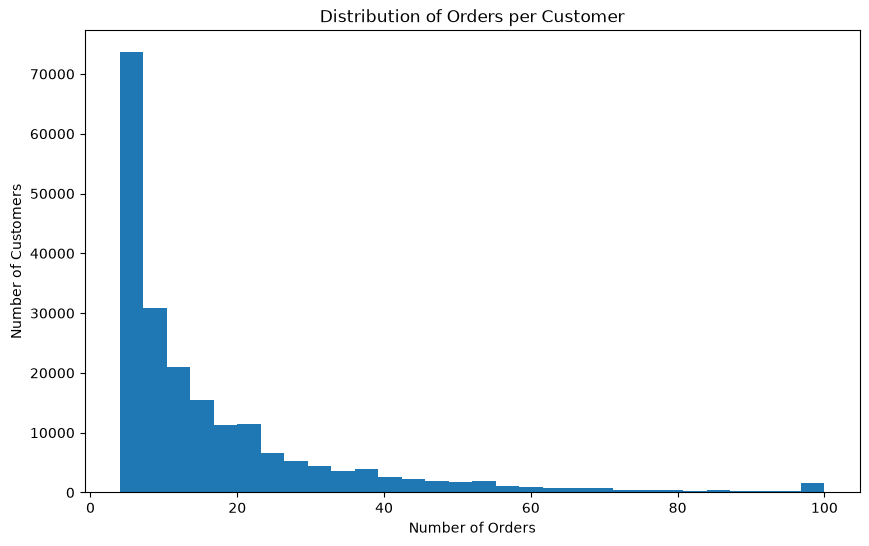

In [34]:
plt.figure(figsize=(10,6))

plt.hist(orders_per_customer["total_orders"], bins=30)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.savefig("/Applications/RetailIQ-Instacart/images/orders_per_customer_distribution.png", bbox_inches="tight")
plt.show()

This is the histogram according to orders_per_customer 

Observation : very least number of customer dis order of 100 and and number of orders 4-5 was did by above 70000 customers 

#### 3. What percentage of orders purchased are reordered by customers ?

In [35]:
# Total purchased products
total_products=len(orders_products)

# Total reordered products
reordered_products=orders_products[orders_products['reordered']==1].shape[0]

# Reorder percentage
reorder_percentage=(reordered_products/total_products)*100

print(f"Reorder Percentage: {reorder_percentage:.2f}%")

Reorder Percentage: 58.97%


So the reordered percentage is 58.79 %

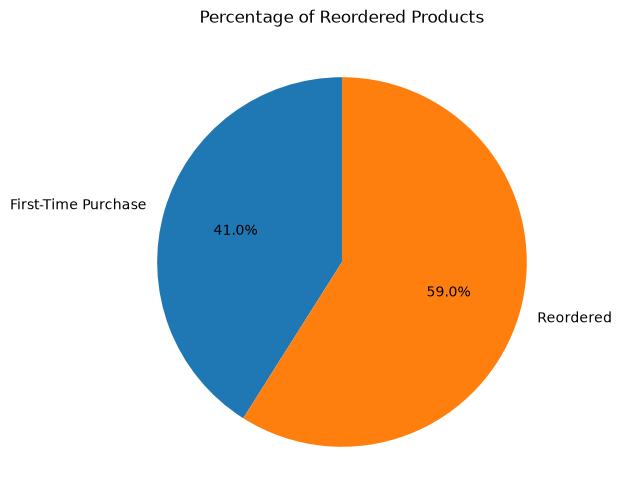

In [36]:
summary = pd.DataFrame({
    "Category": ["First-Time Purchase", "Reordered"],
    "Count": [
        total_products - reordered_products,
        reordered_products
    ]
})

plt.figure(figsize=(6,6))

plt.pie(
    summary["Count"],
    labels=summary["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Reordered Products")
plt.savefig("/Applications/RetailIQ-Instacart/images/reorder_percentage.png", bbox_inches="tight")
plt.show()

I have made this pie chart so that we can differentiate between the first time purchase and reordered products percentage easily

#### 4.⁠ ⁠Which customers exhibit the highest loyalty based on reorder frequency?


In [37]:
# Merging two tables to get customer orders with product details
customer_orders = orders.merge(
    orders_products,
    on="order_id",
    how="inner"
)
customer_orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,1,2,8,NaN,196,1,0
1,2539329,1,1,2,8,NaN,14084,2,0
2,2539329,1,1,2,8,NaN,12427,3,0
3,2539329,1,1,2,8,NaN,26088,4,0
4,2539329,1,1,2,8,NaN,26405,5,0


In [38]:
# Group by user_id to calculate total products purchased and total reordered products 
customer_loyalty = (
    customer_orders
    .groupby("user_id")
    .agg(
        total_products=("product_id", "count"),
        reordered_products=("reordered", "sum")
    )
    .reset_index()
)

In [39]:
# Calculate reorder percentage for each customer
customer_loyalty["reorder_percentage"] = (
    customer_loyalty["reordered_products"] / customer_loyalty["total_products"]
) * 100
customer_loyalty.head()

,user_id,total_products,reordered_products,reorder_percentage
0,1,59,41,69.491525
1,2,195,93,47.692308
2,3,88,55,62.500000
3,4,18,1,5.555556
4,5,37,14,37.837838


In [40]:
# Finding the top 10 customers with the highest reorder percentage
top_loyal_customers = customer_loyalty.sort_values(by="reorder_percentage", ascending=False)

top_loyal_customers.head(10)

,user_id,total_products,reordered_products,reorder_percentage
99752,99753,191,189,98.952880
82413,82414,428,420,98.130841
107527,107528,104,102,98.076923
17996,17997,435,426,97.931034
5587,5588,2223,2176,97.885740
170173,170174,47,46,97.872340
3268,3269,275,269,97.818182
12024,12025,45,44,97.777778
91159,91160,212,207,97.641509
184516,184517,210,205,97.619048


So this is the top 10 loyal customer based on reorder frequency

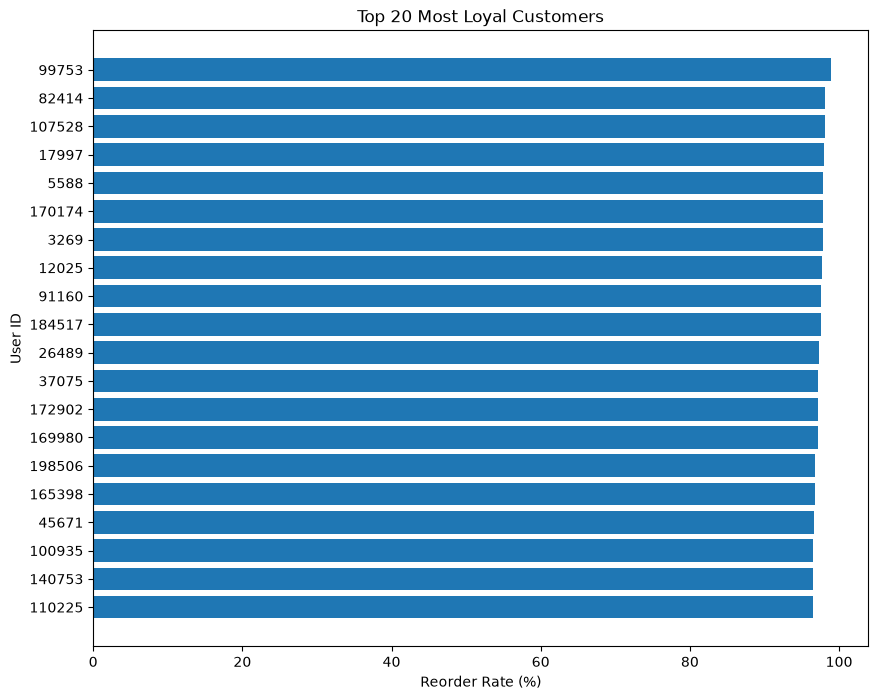

In [41]:
top20 = top_loyal_customers.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["user_id"].astype(str),
    top20["reorder_percentage"]
)

plt.title("Top 20 Most Loyal Customers")
plt.xlabel("Reorder Rate (%)")
plt.ylabel("User ID")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/top_20_loyal_customers.png", bbox_inches="tight")
plt.show()

From here i can see user_id = 99753 is the most loyal customer and there after 81414 and so on according to the bar chart 

Observation : Several customers have reorder rates above 90%
These customers consistently purchase the same products.
Their behavior suggests strong brand or product loyalty.

And also we can offer loyalty rewards to frequent customers and discounts to encourage repeat purchases from occasional shoppers.

#### 5. What is average basket size (number of products per order )?

In [42]:
#calculating Basket Size for each Order 

basket_size = (
    orders_products
    .groupby("order_id")["product_id"]
    .count()
    .reset_index(name="basket_size")
)

basket_size.head()

,order_id,basket_size
0,2,9
1,3,8
2,4,13
3,5,26
4,6,3


In [43]:
# calculate the Average Basket Size

average_basket = basket_size["basket_size"].mean()

print(f"Average Basket Size: {average_basket:.2f} products")

Average Basket Size: 10.09 products


So , the average basket size is 10.09 products

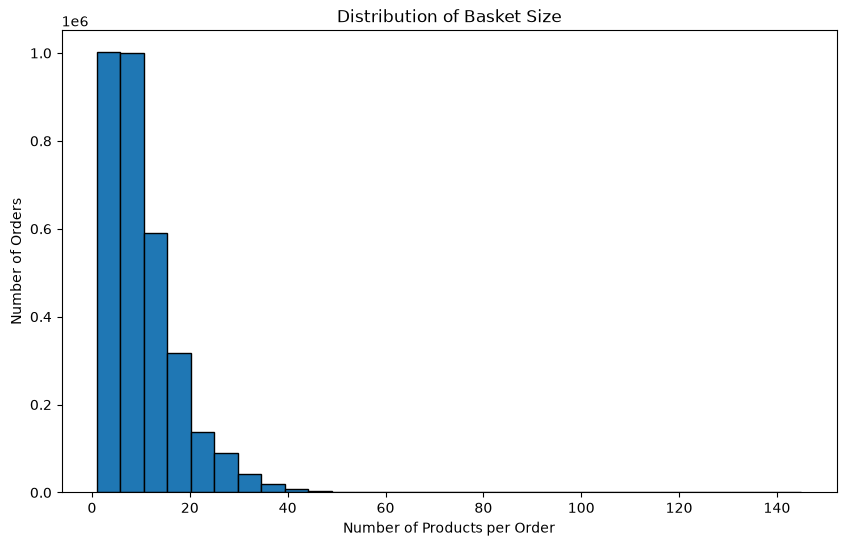

In [44]:
plt.figure(figsize=(10,6))

plt.hist(
    basket_size["basket_size"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Basket Size")
plt.xlabel("Number of Products per Order")
plt.ylabel("Number of Orders")

plt.savefig("/Applications/RetailIQ-Instacart/images/basket_size_distribution.png", bbox_inches="tight")
plt.show()

This is distribution of number of orders with number of products per order 

Observation : Number of products per order when >=40 then the number of product is very less and when number of products per order is >0 and <=5 then distribution is almost 1 

### Product Performance

#### 6. Which are the top 20 most frequently ordered products ?

In [45]:
# Counting how many time seach product was ordered

top_products = (
    orders_products
    .groupby("product_id")
    .size()
    .reset_index(name="total_orders")
)

top_products

,product_id,total_orders
0,1,1852
1,2,90
2,3,277
3,4,329
4,5,15
...,...,...
49672,49684,9
49673,49685,49
49674,49686,120
49675,49687,13


In [46]:
# Merging with product table 

top_products = top_products.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

top_products


,product_id,total_orders,product_name
0,1,1852,Chocolate Sandwich Cookies
1,2,90,All-Seasons Salt
2,3,277,Robust Golden Unsweetened Oolong Tea
3,4,329,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,5,15,Green Chile Anytime Sauce
...,...,...,...
49672,49684,9,"Vodka, Triple Distilled, Twist of Vanilla"
49673,49685,49,En Croute Roast Hazelnut Cranberry
49674,49686,120,Artisan Baguette
49675,49687,13,Smartblend Healthy Metabolism Dry Cat Food


In [47]:
# Sorting and selecting the top 20 

top_products = (
    top_products
    .sort_values(by="total_orders", ascending=False)
    .head(20)
)

top_products

,product_id,total_orders,product_name
24848,24852,472565,Banana
13172,13176,379450,Bag of Organic Bananas
21133,21137,264683,Organic Strawberries
21899,21903,241921,Organic Baby Spinach
47198,47209,213584,Organic Hass Avocado
47755,47766,176815,Organic Avocado
47615,47626,152657,Large Lemon
16793,16797,142951,Strawberries
26204,26209,140627,Limes
27839,27845,137905,Organic Whole Milk


So the ordered product is Banana with 472565 number of orders .

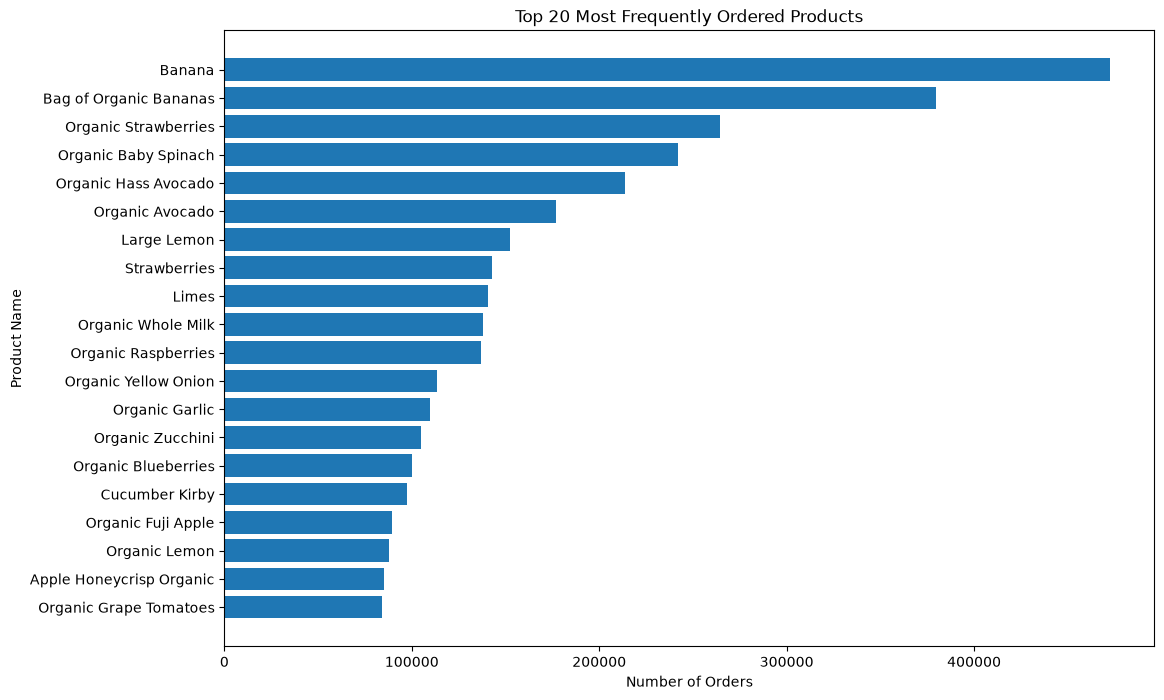

In [48]:
plt.figure(figsize=(12,8))

plt.barh(
    top_products["product_name"],
    top_products["total_orders"]
)

plt.title("Top 20 Most Frequently Ordered Products")
plt.xlabel("Number of Orders")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/top_20_products.png", bbox_inches="tight")
plt.show()

So from the visualization i can see banana has much more order than any other products 


Observation : So we need to make our stock very high for the high demand products like Banana and Bag of organic Bananas


#### 7.⁠ ⁠Which products have the highest reorder rates?

In [49]:
#Calculate Reorder Rate
product_reorder = (
    orders_products
    .groupby("product_id")
    .agg(
        total_orders=("product_id", "count"),
        total_reorders=("reordered", "sum")
    )
    .reset_index()
)

product_reorder["reorder_rate"] = (
    product_reorder["total_reorders"]
    / product_reorder["total_orders"]
) * 100

product_reorder = product_reorder.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

product_reorder


,product_id,total_orders,total_reorders,reorder_rate,product_name
0,1,1852,1136,61.339093,Chocolate Sandwich Cookies
1,2,90,12,13.333333,All-Seasons Salt
2,3,277,203,73.285199,Robust Golden Unsweetened Oolong Tea
3,4,329,147,44.680851,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,5,15,9,60.000000,Green Chile Anytime Sauce
...,...,...,...,...,...
49672,49684,9,1,11.111111,"Vodka, Triple Distilled, Twist of Vanilla"
49673,49685,49,6,12.244898,En Croute Roast Hazelnut Cranberry
49674,49686,120,84,70.000000,Artisan Baguette
49675,49687,13,6,46.153846,Smartblend Healthy Metabolism Dry Cat Food


In [50]:
# Here i am taking the products with >=100 total orders

product_reorder = product_reorder[
    product_reorder["total_orders"] >= 100
]

In [51]:
# Here the top 20 products with the highest reorder rate

top_reordered = (
    product_reorder
    .sort_values(by="reorder_rate", ascending=False)
    .head(20)
)


top_reordered

,product_id,total_orders,total_reorders,reorder_rate,product_name
27734,27740,101,93,92.079208,Chocolate Love Bar
35598,35604,100,90,90.000000,Maca Buttercups
38243,38251,111,99,89.189189,Benchbreak Chardonnay
10232,10236,129,113,87.596899,Fragrance Free Clay with Natural Odor Eliminat...
20594,20598,112,98,87.500000,Thousand Island Salad Snax
35490,35496,451,389,86.252772,Real2 Alkalized Water 500 ml
9288,9292,2921,2517,86.169120,Half And Half Ultra Pasteurized
45495,45504,9108,7835,86.023276,Whole Organic Omega 3 Milk
43386,43394,8477,7282,85.903032,Organic Lactose Free Whole Milk
5511,5514,3970,3405,85.768262,Organic Homogenized Whole Milk


So, Chocolate Love Bar is the product wth highest reorder rate 

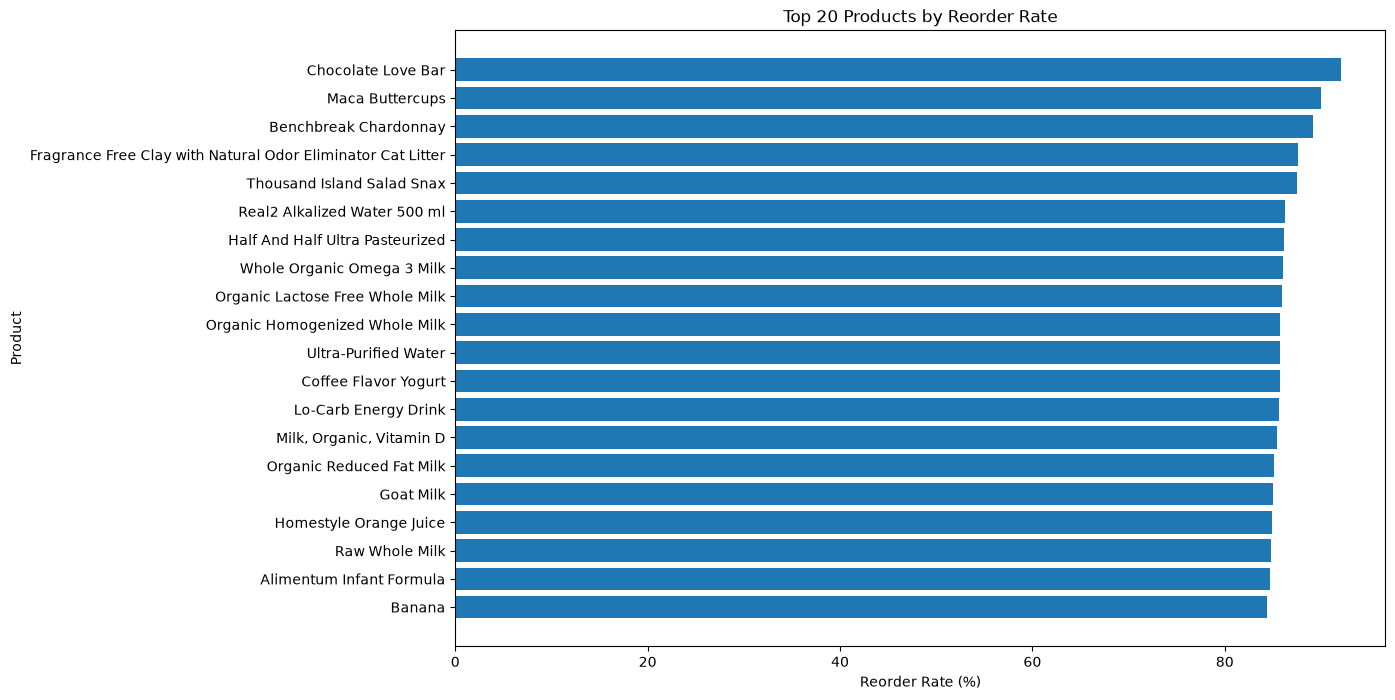

In [52]:
plt.figure(figsize=(12,8))

plt.barh(
    top_reordered["product_name"],
    top_reordered["reorder_rate"]
)

plt.title("Top 20 Products by Reorder Rate")
plt.xlabel("Reorder Rate (%)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/top_20_reordered_products.png", bbox_inches="tight")
plt.show()

Observation : Since this products are top 20 products with above 80% reorder rate so we need to make this product's stock high

#### 8.⁠ ⁠Which products are rarely purchased and may require promotional strategies?

In [53]:
#Counting the number of orders per product

low_selling_products = (
    orders_products
    .groupby("product_id")
    .size()
    .reset_index(name="total_orders")
)

In [54]:
# Merging with product name and sorting in ascending order 

low_selling_products = low_selling_products.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

low_selling_products = low_selling_products.sort_values(by="total_orders", ascending=True)

low_selling_products.head(20)

rare_products = low_selling_products[
    low_selling_products["total_orders"] <=10
]

top20_rare=rare_products.head(20)

top20_rare

,product_id,total_orders,product_name
14752,14756,1,"Frittata, Farmer's Market"
23649,23653,1,Aged Parmesan Cheese Sticks
45264,45273,1,Flame Roasted Red Peppers Spreadable Cheese
47669,47680,1,Indian Wells Merlot
23620,23624,1,Flatbread Pizza All Natural
36073,36079,1,Pumpkin Spice Almond Nog
28498,28504,1,Escapes Variety Pack
7708,7712,1,String Of Pearl White Sprinkles
13393,13397,1,"Molasses, Bead"
15897,15901,1,Bite Size Caramel Chocolates


This are the products  with less order number

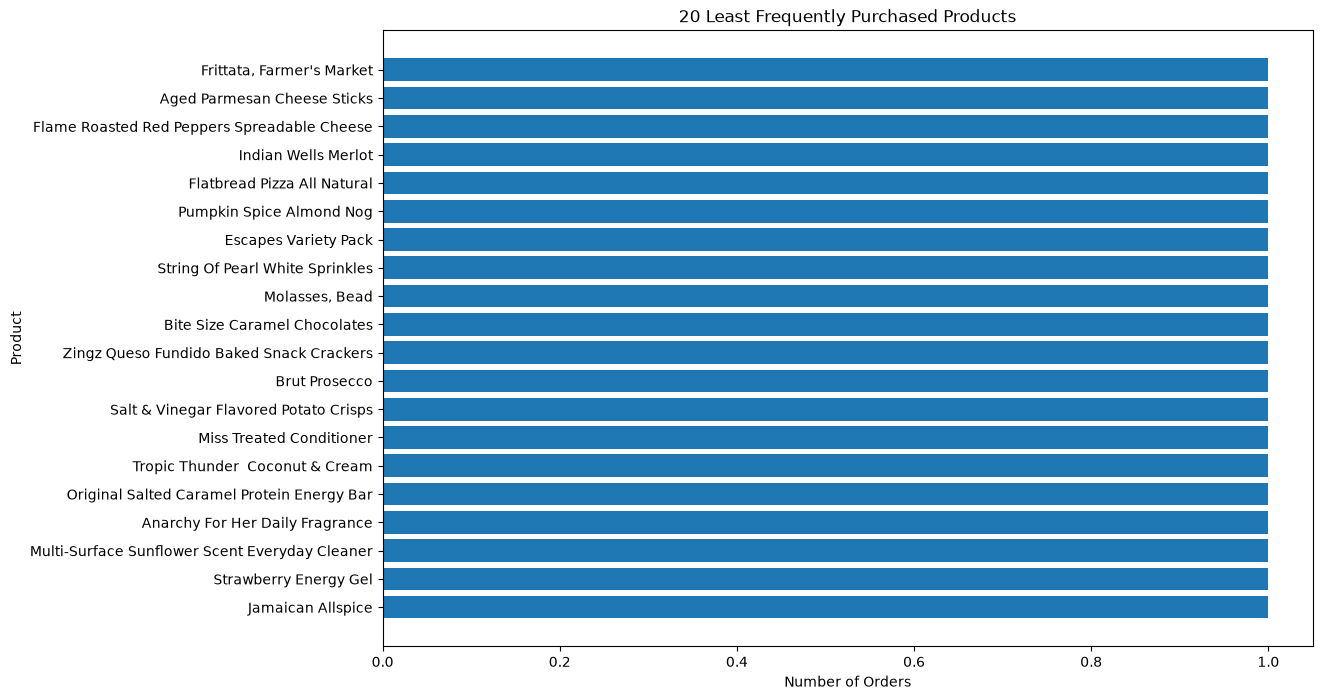

In [57]:
plt.figure(figsize=(12,8))

plt.barh(
    top20_rare["product_name"],
    top20_rare["total_orders"]
)

plt.title("20 Least Frequently Purchased Products")
plt.xlabel("Number of Orders")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/top_20_rare_products.png", bbox_inches="tight")
plt.show()

This is the barchart for least ordering top 20 products

####  9.⁠ ⁠Which products contribute the most to customers' shopping baskets?


In [58]:
basket_products = (
    orders_products
    .groupby("product_id")
    .agg(
        basket_count=("order_id", "count")
    )
    .reset_index()
)

basket_products = basket_products.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

top20_basket_products = basket_products.sort_values(by="basket_count", ascending=False).head(20)

top20_basket_products

,product_id,basket_count,product_name
24848,24852,472565,Banana
13172,13176,379450,Bag of Organic Bananas
21133,21137,264683,Organic Strawberries
21899,21903,241921,Organic Baby Spinach
47198,47209,213584,Organic Hass Avocado
47755,47766,176815,Organic Avocado
47615,47626,152657,Large Lemon
16793,16797,142951,Strawberries
26204,26209,140627,Limes
27839,27845,137905,Organic Whole Milk


From here i can see Banana has the highest basket count 

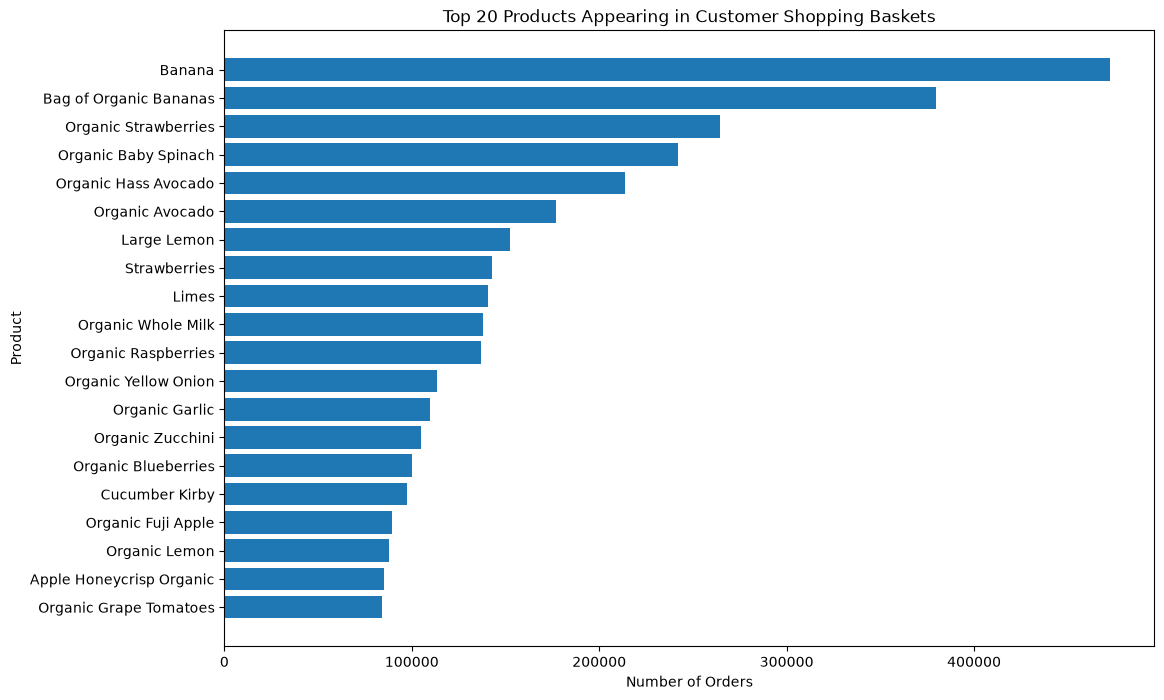

In [59]:
plt.figure(figsize=(12,8))

plt.barh(
    top20_basket_products["product_name"],
    top20_basket_products["basket_count"]
)

plt.title("Top 20 Products Appearing in Customer Shopping Baskets")
plt.xlabel("Number of Orders")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/top_20_basket_products.png", bbox_inches="tight")
plt.show()

Observation : So Product Banana contains most of the basket by customers

#### 10.⁠ ⁠Which products are commonly purchased together?


In [60]:
basket = (
    orders_products
    .groupby("order_id")["product_id"]
    .apply(list)
)

basket.head()

order_id
2    [33120, 28985, 9327, 45918, 30035, 17794, 4014...
3    [33754, 24838, 17704, 21903, 17668, 46667, 174...
4    [46842, 26434, 39758, 27761, 10054, 21351, 225...
5    [13176, 15005, 47329, 27966, 23909, 48370, 132...
6                                [40462, 15873, 41897]
Name: product_id, dtype: object

In [61]:
from itertools import combinations

pairs = []

for products_in_order in basket:
    if len(products_in_order) > 1:
        pairs.extend(combinations(sorted(products_in_order), 2))


In [63]:
from collections import Counter

pair_counts = Counter(pairs)

In [64]:
pair_df = pd.DataFrame(
    pair_counts.items(),
    columns=["product_pair", "frequency"]
)

pair_df[["product_1", "product_2"]] = pd.DataFrame(
    pair_df["product_pair"].tolist(),
    index=pair_df.index
)

In [65]:
pair_df = pair_df.merge(
    products[["product_id", "product_name"]],
    left_on="product_1",
    right_on="product_id"
).rename(columns={"product_name": "product_1_name"})

pair_df = pair_df.merge(
    products[["product_id", "product_name"]],
    left_on="product_2",
    right_on="product_id"
).rename(columns={"product_name": "product_2_name"})

In [66]:
top_pairs = (
    pair_df
    .sort_values("frequency", ascending=False)
    .head(20)
)

top_pairs[["product_1_name", "product_2_name", "frequency"]]

,product_1_name,product_2_name,frequency
271,Bag of Organic Bananas,Organic Hass Avocado,62341
13198,Bag of Organic Bananas,Organic Strawberries,61628
637,Organic Strawberries,Banana,56156
658,Banana,Organic Avocado,53395
1637,Organic Baby Spinach,Banana,51395
11584,Bag of Organic Bananas,Organic Baby Spinach,50372
10266,Strawberries,Banana,41232
2713,Banana,Large Lemon,40880
3070,Organic Strawberries,Organic Hass Avocado,40794
264,Bag of Organic Bananas,Organic Raspberries,40503


So Bags of Organic Banana with Organic Hass Avocado is the most ordered pair with 62341 times 

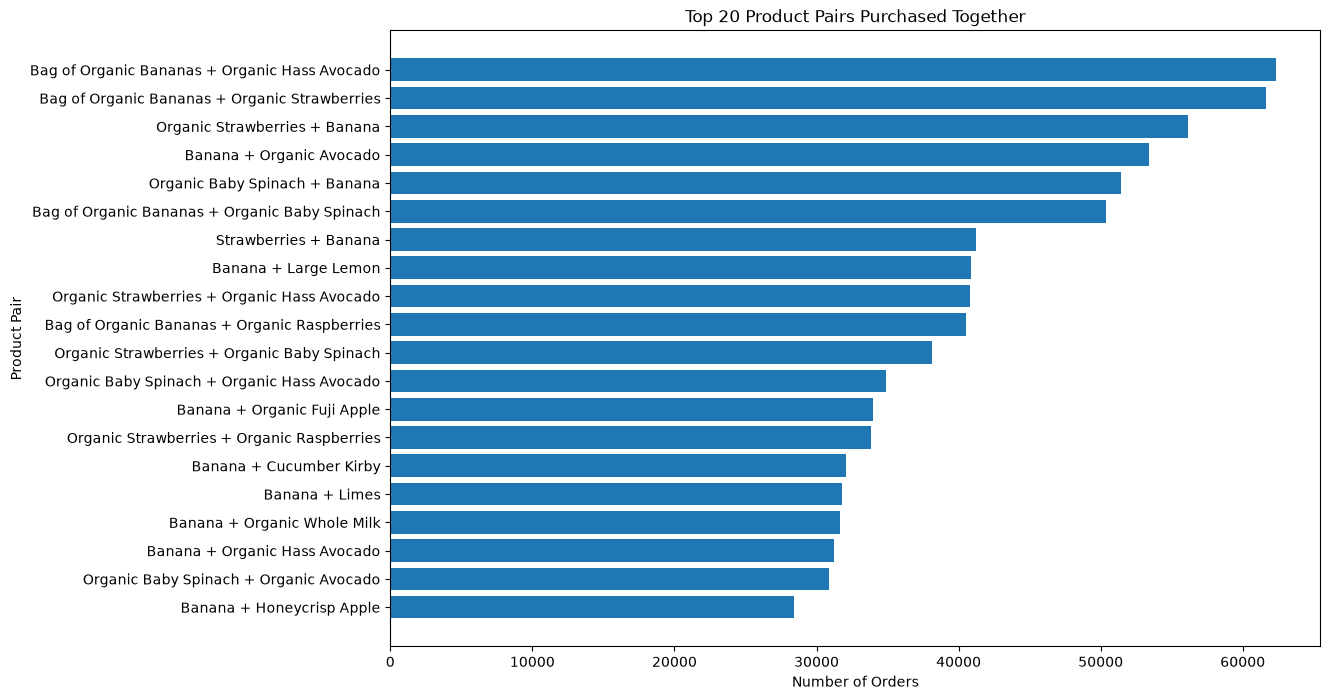

In [68]:
top_pairs["pair"] = (
    top_pairs["product_1_name"] +
    " + " +
    top_pairs["product_2_name"]
)

plt.figure(figsize=(12,8))

plt.barh(
    top_pairs["pair"],
    top_pairs["frequency"]
)

plt.title("Top 20 Product Pairs Purchased Together")
plt.xlabel("Number of Orders")
plt.ylabel("Product Pair")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/top_20_product_pairs.png", bbox_inches="tight")
plt.show()

Observation : So Bags of Organic Bananas with Organic Hass Avocado and Bags of Organic Bananas with Organic Strawberries has the most paired ordered items with above 60000 ordered frequency

And also we can recommend complementary products when customers add one of the products to their cart.

### Department & Aisle Analysis


#### 11.⁠ ⁠Which departments receive the highest number of orders?


In [72]:
# Merging orders_products with products to get product names

dept_orders = orders_products.merge(
    products,
    on="product_id",
    how="left"
)

# Merging with departments

dept_orders = dept_orders.merge(departments, on="department_id", how="left")

# Counting Orders by Department

department_orders = (
    dept_orders
    .groupby("department")["order_id"]
    .count()
    .reset_index(name="total_orders")
)

# Sorting in descending order

department_orders = department_orders.sort_values(by="total_orders", ascending=False)

department_orders

,department,total_orders
19,produce,9479291
7,dairy eggs,5414016
20,snacks,2887550
3,beverages,2690129
10,frozen,2236432
16,pantry,1875577
2,bakery,1176787
6,canned goods,1068058
8,deli,1051249
9,dry goods pasta,866627


From here I can see produce department has the most orders with 9479291 orders

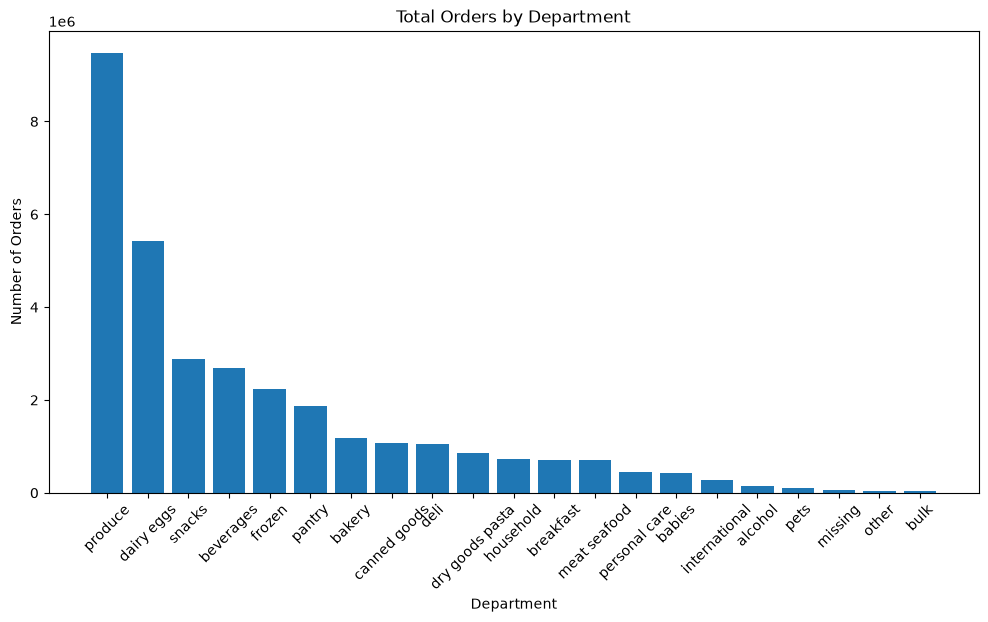

In [74]:
plt.figure(figsize=(12,6))

plt.bar(
    department_orders["department"],
    department_orders["total_orders"]
)

plt.title("Total Orders by Department")
plt.xlabel("Department")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.savefig("/Applications/RetailIQ-Instacart/images/total_orders_by_department.png", bbox_inches="tight")  
plt.show()

Observation : Since orders in the produce department is very high so we have make our stocks very high for the department and bulk department has very least orders so we don't need very much stock for it or it will be a total waste

#### 12.⁠ ⁠Which aisles are the most popular among customers?


In [75]:
# Merging orders_products with products to get product names

aisle_orders = orders_products.merge(
    products,
    on="product_id",
    how="left"
)

# Merging with aisles

aisle_orders = aisle_orders.merge(aisles, on="aisle_id", how="left")

# Counting Orders by Aisle and sorting in descending order

popular_aisles = (
    aisle_orders
    .groupby("aisle")["order_id"]
    .count()
    .reset_index(name="total_orders")
)

popular_aisles = popular_aisles.sort_values(
    by="total_orders",
    ascending=False
)

popular_aisles.head(20)


,aisle,total_orders
50,fresh fruits,3642188
53,fresh vegetables,3418021
98,packaged vegetables fruits,1765313
133,yogurt,1452343
93,packaged cheese,979763
83,milk,891015
131,water seltzer sparkling water,841533
25,chips pretzels,722470
119,soy lactosefree,638253
11,bread,584834


So , fresh fruits is the total popular aisle according to total orders with # Merging orders_products with 3642188 number of orders in that aisle.

In [76]:
top20_aisles = popular_aisles.head(20)

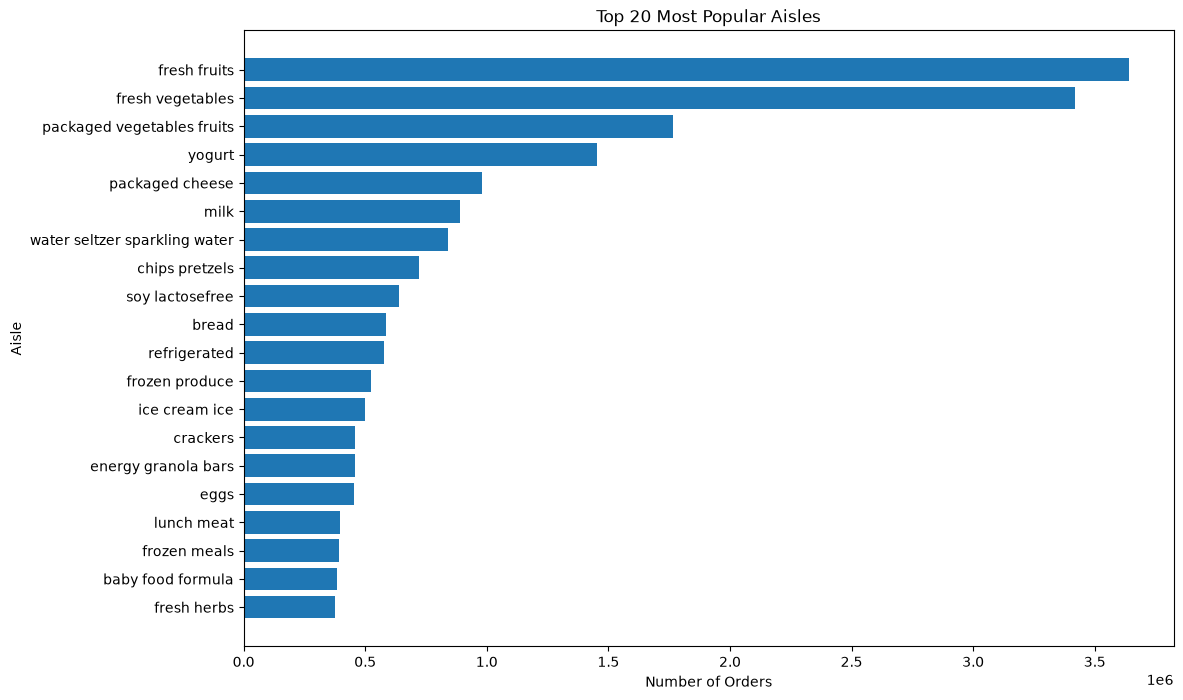

In [86]:
plt.figure(figsize=(12,8))

plt.barh(
    top20_aisles["aisle"],
    top20_aisles["total_orders"]
)

plt.title("Top 20 Most Popular Aisles")
plt.xlabel("Number of Orders")
plt.ylabel("Aisle")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/top_20_aisles.png", bbox_inches="tight")
plt.show()

Observation : So fresh fruits and fresh vegetables are the most popular aisles according to total orders

#### 13.⁠ ⁠Which departments have the highest product reorder rates?


In [78]:
# Merging orders_products with products to get product names

dept_reorder = orders_products.merge(
    products,
    on="product_id",
    how="left"
)

# Merging with departments to get department names
dept_reorder = dept_reorder.merge(
    departments,
    on="department_id",
    how="left"
)

In [79]:
# Calculating reorder rate by department

department_reorder = (
    dept_reorder
    .groupby("department")
    .agg(
        total_products=("product_id", "count"),
        reordered_products=("reordered", "sum")
    )
    .reset_index()
)

department_reorder["reorder_rate"] = (
    department_reorder["reordered_products"]
    / department_reorder["total_products"]
) * 100


In [80]:
# Sorting in descending order

department_reorder = department_reorder.sort_values(
    by="reorder_rate",
    ascending=False
)

department_reorder

,department,total_products,reordered_products,reorder_rate
7,dairy eggs,5414016,3627221,66.996865
3,beverages,2690129,1757892,65.346011
19,produce,9479291,6160710,64.991253
2,bakery,1176787,739188,62.814086
8,deli,1051249,638864,60.771901
18,pets,97724,58760,60.128525
1,babies,423802,245369,57.897084
5,bulk,34573,19950,57.703989
20,snacks,2887550,1657973,57.417984
0,alcohol,153696,87595,56.992375


So , most reordered department is dairy eggs with reordered_products 3627221 and reordered rate 66.996865 % 

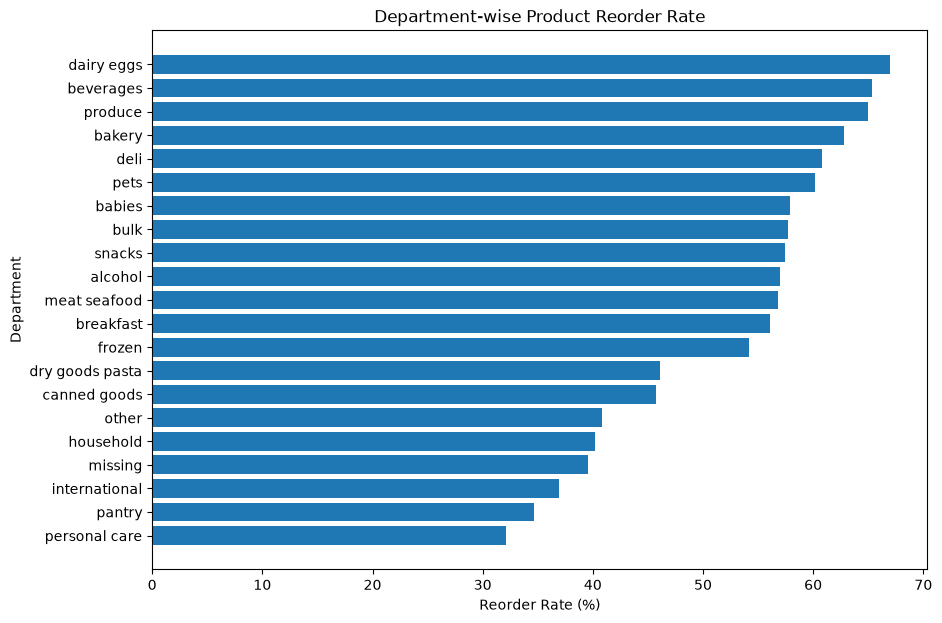

In [87]:
plt.figure(figsize=(10,7))

plt.barh(
    department_reorder["department"],
    department_reorder["reorder_rate"]
)

plt.title("Department-wise Product Reorder Rate")
plt.xlabel("Reorder Rate (%)")
plt.ylabel("Department")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/department_reorder_rate.png", bbox_inches="tight")
plt.show()

Observation : dairy eggs , bevarages , produce has the most reordered department with almost above 65 % and personal care is the lowest reordered department 

#### 14.⁠ ⁠Which aisles contain products with the strongest customer loyalty?


In [83]:
# Merging Tables 

aisle_reorder = orders_products.merge(
    products,
    on="product_id",
    how="left"
)

aisle_reorder = aisle_reorder.merge(
    aisles,
    on="aisle_id",
    how="left"
)

# Calculating reorder products and total products by aisle

aisle_loyalty = (
    aisle_reorder
    .groupby("aisle")
    .agg(
        total_products=("product_id", "count"),
        reordered_products=("reordered", "sum")
    )
    .reset_index()
)

# Calculating reorder rate by aisle

aisle_loyalty["reorder_rate"] = (
    aisle_loyalty["reordered_products"]
    / aisle_loyalty["total_products"]
) * 100

# Removing aisles with less than 100 total products

aisle_loyalty = aisle_loyalty[aisle_loyalty["total_products"] >= 100]

# Sorting in descending order
aisle_loyalty = (aisle_loyalty.sort_values(by="reorder_rate", ascending=False))

aisle_loyalty.head(20)

,aisle,total_products,reordered_products,reorder_rate
83,milk,891015,696264,78.142792
131,water seltzer sparkling water,841533,613977,72.959349
50,fresh fruits,3642188,2615469,71.810379
41,eggs,452134,318920,70.536611
119,soy lactosefree,638253,442023,69.255139
96,packaged produce,276028,190662,69.073427
133,yogurt,1452343,997018,68.648935
33,cream,318002,217846,68.504601
11,bread,584834,391937,67.016795
110,refrigerated,575881,381983,66.330197


So , milk aisle is the most reordered aisle with 696264 products and 78.142792 % reordered rate

In [84]:
top20_loyal_aisles = aisle_loyalty.head(20)

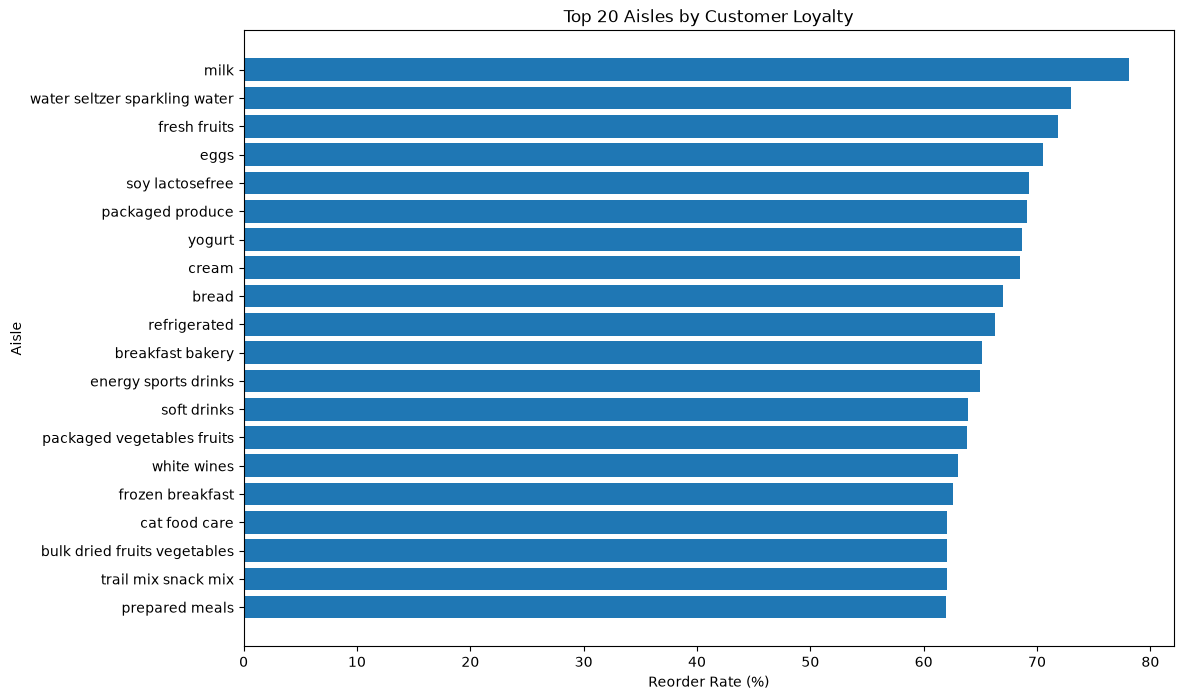

In [88]:
plt.figure(figsize=(12,8))

plt.barh(
    top20_loyal_aisles["aisle"],
    top20_loyal_aisles["reorder_rate"]
)

plt.title("Top 20 Aisles by Customer Loyalty")
plt.xlabel("Reorder Rate (%)")
plt.ylabel("Aisle")

plt.gca().invert_yaxis()

plt.savefig("/Applications/RetailIQ-Instacart/images/top_20_loyal_aisles.png", bbox_inches="tight")
plt.show()

Observation : milk aisle is the most reordered aisle with almost 80% reordered rate

### Order & Time Analysis


#### 15.⁠ ⁠On which days of the week are the highest numbers of orders placed?


In [104]:
# Counting orders by day of the week

orders_by_day = (
    orders.groupby("order_dow")["order_id"]
    .count()
    .reset_index(name="total_orders")
)

orders_by_day

,order_dow,total_orders
0,0,600905
1,1,587478
2,2,467260
3,3,436972
4,4,426339
5,5,453368
6,6,448761


In [105]:
# Replacing Numbers with Day Names
day_mapping = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}



In [106]:
orders_by_day["day_name"] = orders_by_day["order_dow"].map(day_mapping)

In [107]:
orders_by_day

,order_dow,total_orders,day_name
0,0,600905,Sunday
1,1,587478,Monday
2,2,467260,Tuesday
3,3,436972,Wednesday
4,4,426339,Thursday
5,5,453368,Friday
6,6,448761,Saturday


So , Sunday and Monday have the most orders with orders above 58000 

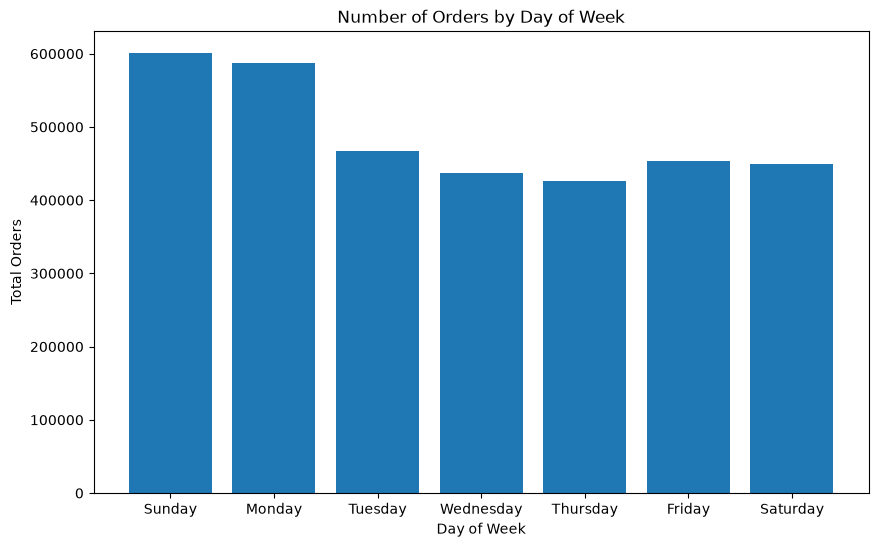

In [109]:
plt.figure(figsize=(10,6))

plt.bar(
    orders_by_day["day_name"],
    orders_by_day["total_orders"]
)

plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Orders")

plt.savefig("/Applications/RetailIQ-Instacart/images/orders_by_day.png", bbox_inches="tight")
plt.show()

Observation : So Sunday and monday have the most number of orders in a week so we have to make our stocks high for those days 

#### 16.⁠ ⁠During which hours of the day is customer activity at its peak?


In [113]:
# Counting orders by hour of the day

orders_by_hour = (
    orders
    .groupby("order_hour_of_day")
    .size()
    .reset_index(name="total_orders")
)

orders_by_hour.sort_values(by="total_orders", ascending=False, inplace=True)

orders_by_hour

,order_hour_of_day,total_orders
10,10,288418
11,11,284728
15,15,283639
14,14,283042
13,13,277999
12,12,272841
16,16,272553
9,9,257812
17,17,228795
18,18,182912


So most of the orders has been placed in the morning 10.00 A.M. of a day

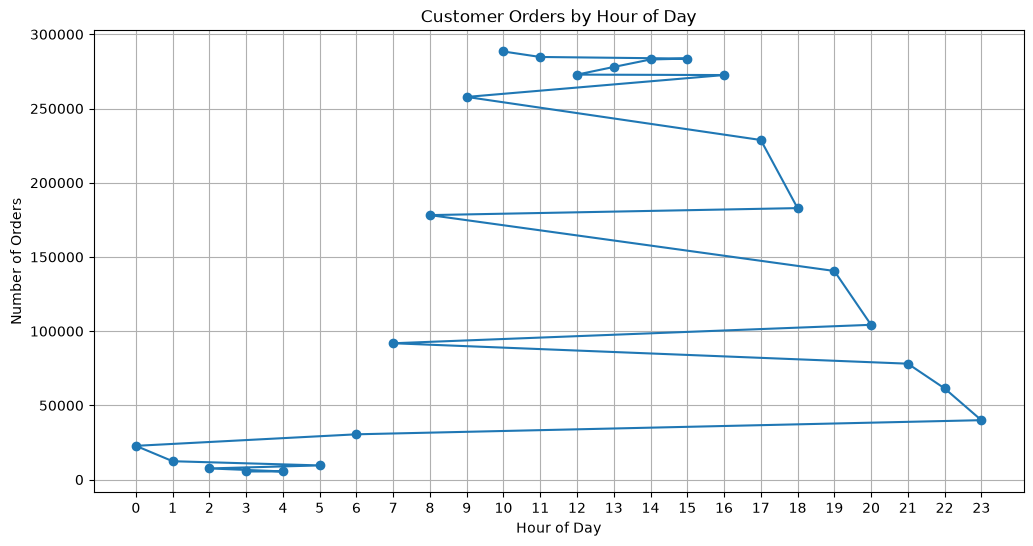

In [115]:
plt.figure(figsize=(12,6))

plt.plot(
    orders_by_hour["order_hour_of_day"],
    orders_by_hour["total_orders"],
    marker="o"
)

plt.title("Customer Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(24))

plt.grid(True)

plt.savefig("/Applications/RetailIQ-Instacart/images/orders_by_hour.png", bbox_inches="tight")
plt.show()

Observation : So, morning 10 a.m. is the most ordered time and the least ordered made in the 3 a.m. of a day and from the graph we can see number of order placed vs time is not gradually increasing , so people demand very much varies 

And also we can schedule promotional notifications before these peak shopping hours(10 AM - 2 PM).

#### 17.⁠ ⁠How does customer ordering behavior vary between weekdays and weekends?


In [119]:
# First creating a new column to categorize weekend and weekday orders
orders["day_type"] = orders["order_dow"].apply(lambda x: "Weekend" if x in [0, 6] else "Weekday")

# Counting the orders by day type

orders_by_day_type = (
    orders
    .groupby("day_type")["order_id"]
    .count()
    .reset_index(name="total_orders")
)

orders_by_day_type

,day_type,total_orders
0,Weekday,2371417
1,Weekend,1049666


In [120]:
# Calculating percentage of orders for each day type

orders_by_day_type["percentage"] = (
    orders_by_day_type["total_orders"]
    / orders_by_day_type["total_orders"].sum()
) * 100

orders_by_day_type

,day_type,total_orders,percentage
0,Weekday,2371417,69.317728
1,Weekend,1049666,30.682272


So , We can See almost 30 % of the total order has been made in the weekends 

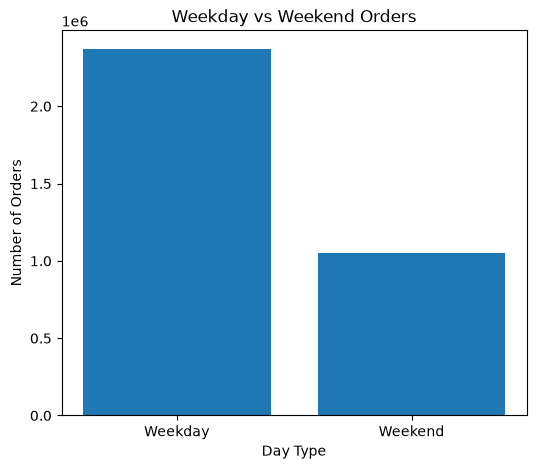

In [122]:
plt.figure(figsize=(6,5))

plt.bar(
    orders_by_day_type["day_type"],
    orders_by_day_type["total_orders"]
)

plt.title("Weekday vs Weekend Orders")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")

plt.savefig("/Applications/RetailIQ-Instacart/images/orders_by_day_type.png", bbox_inches="tight")
plt.show()

Observation : A larger share of orders is placed on weekdays because there are five weekdays compared to two weekend days.
Weekend order volume remains high despite there being fewer days, indicating strong shopping activity on Saturdays and Sundays.

#### 18.⁠ ⁠How does the number of products purchased vary by time of day?


In [125]:
# Merging two tables to get customer orders with product details

hourly_products = orders.merge(
    orders_products,
    on="order_id",
    how="inner"
)

# Counting the number of orders by hour of the day

products_by_hour = (
    hourly_products
    .groupby("order_hour_of_day")
    .agg(
        total_products=("product_id", "count")
    )
    .reset_index()
)

products_by_hour

,order_hour_of_day,total_products
0,0,218948
1,1,115786
2,2,69434
3,3,51321
4,4,53283
5,5,88062
6,6,290795
7,7,891937
8,8,1719973
9,9,2456713


This is the table for the number of orders per hour of a day

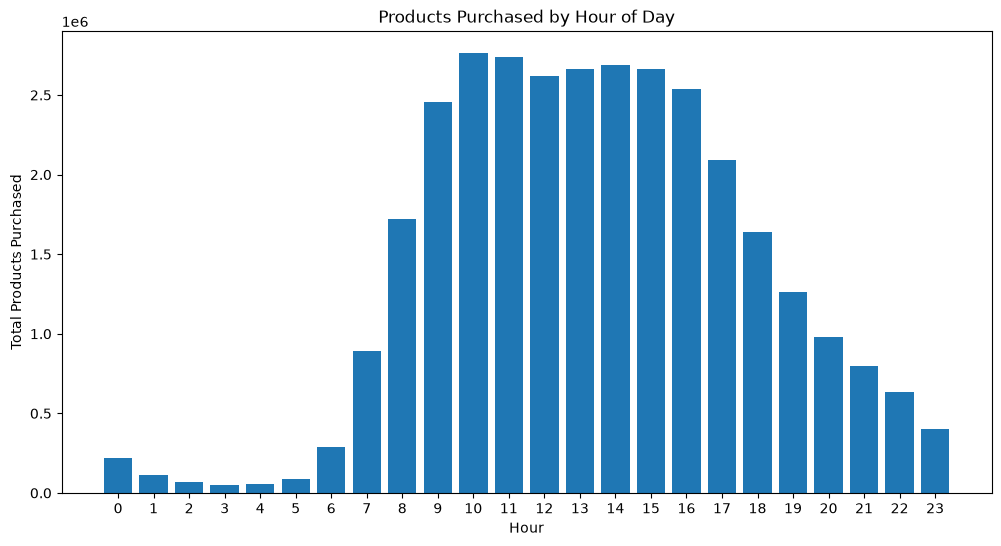

In [128]:
plt.figure(figsize=(12,6))

plt.bar(
    products_by_hour["order_hour_of_day"],
    products_by_hour["total_products"]
)

plt.title("Products Purchased by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Products Purchased")

plt.xticks(range(24))

plt.savefig("/Applications/RetailIQ-Instacart/images/products_by_hour.png", bbox_inches="tight")
plt.show()

Here we can see the total number of products purchased vs hour of the day graph .